In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import load_img, img_to_array


In [58]:
MODEL_PATH = "models/mustache_detector2.keras"

CLEAN_DIR = "data/dataset_v3/clean"
MUSTACHE_DIR = "data/dataset_v3/mustache"

IMG_SIZE = (178, 178)   # ändra om modellen tränades med annan storlek
THRESHOLD = 0.5

In [59]:
model = load_model(MODEL_PATH)

In [51]:
rows = []

for true_label, folder, true_name in [
    (0, CLEAN_DIR, "clean"),
    (1, MUSTACHE_DIR, "mustache")
]:
    files = [
        f for f in os.listdir(folder)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    for i, fname in enumerate(files):
        path = os.path.join(folder, fname)

        img = load_img(path, target_size=IMG_SIZE)
        arr = img_to_array(img)
        arr = np.expand_dims(arr, axis=0)

        prob = float(model.predict(arr, verbose=0)[0][0])
        pred_label = 1 if prob >= THRESHOLD else 0
        pred_name = "mustache" if pred_label == 1 else "clean"

        confidence = prob if pred_label == 1 else 1 - prob

        rows.append({
            "filename": fname,
            "path": path,
            "true_label": true_label,
            "true_name": true_name,
            "pred_label": pred_label,
            "pred_name": pred_name,
            "mustache_prob": prob,
            "confidence": confidence,
            "correct": pred_label == true_label
        })

        if (i + 1) % 500 == 0:
            print(f"{true_name}: {i+1}/{len(files)} klara")

df = pd.DataFrame(rows)

clean: 500/5073 klara
clean: 1000/5073 klara
clean: 1500/5073 klara
clean: 2000/5073 klara
clean: 2500/5073 klara
clean: 3000/5073 klara
clean: 3500/5073 klara
clean: 4000/5073 klara
clean: 4500/5073 klara
clean: 5000/5073 klara
mustache: 500/5898 klara
mustache: 1000/5898 klara
mustache: 1500/5898 klara
mustache: 2000/5898 klara
mustache: 2500/5898 klara
mustache: 3000/5898 klara
mustache: 3500/5898 klara
mustache: 4000/5898 klara
mustache: 4500/5898 klara
mustache: 5000/5898 klara
mustache: 5500/5898 klara


In [52]:
print("Totalt:", len(df))
print("Rätt:", df["correct"].sum())
print("Fel:", (~df["correct"]).sum())
print("Accuracy:", df["correct"].mean())

Totalt: 10971
Rätt: 10500
Fel: 471
Accuracy: 0.957068635493574


In [53]:
errors = df[df["correct"] == False].copy()
errors = errors.sort_values("confidence", ascending=False)

errors.head(30)

,filename,path,true_label,true_name,pred_label,pred_name,mustache_prob,confidence,correct
9017,006980.jpg,data/dataset_v3/mustache/006980.jpg,1,mustache,0,clean,0.001869,0.998131,False
979,196123.jpg,data/dataset_v3/clean/196123.jpg,0,clean,1,mustache,0.997926,0.997926,False
6552,100630.jpg,data/dataset_v3/mustache/100630.jpg,1,mustache,0,clean,0.002106,0.997894,False
6608,116790.jpg,data/dataset_v3/mustache/116790.jpg,1,mustache,0,clean,0.002636,0.997364,False
8599,102856.jpg,data/dataset_v3/mustache/102856.jpg,1,mustache,0,clean,0.003907,0.996093,False
7154,103957.jpg,data/dataset_v3/mustache/103957.jpg,1,mustache,0,clean,0.004342,0.995658,False
8628,061881.jpg,data/dataset_v3/mustache/061881.jpg,1,mustache,0,clean,0.005891,0.994109,False
9290,021938.jpg,data/dataset_v3/mustache/021938.jpg,1,mustache,0,clean,0.008815,0.991185,False
9250,135031.jpg,data/dataset_v3/mustache/135031.jpg,1,mustache,0,clean,0.009217,0.990783,False
1084,082578.jpg,data/dataset_v3/clean/082578.jpg,0,clean,1,mustache,0.990450,0.990450,False


In [54]:
def show_images(dataframe, n=25, title="Felgissningar"):
    sample = dataframe.head(n)

    cols = 5
    rows = int(np.ceil(len(sample) / cols))

    plt.figure(figsize=(15, rows * 3))

    for i, (_, row) in enumerate(sample.iterrows()):
        img = Image.open(row["path"])

        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.axis("off")

        plt.title(
            f"True: {row['true_name']}\n"
            f"Pred: {row['pred_name']}\n"
            f"P: {row['mustache_prob']:.2f}"
        )

    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

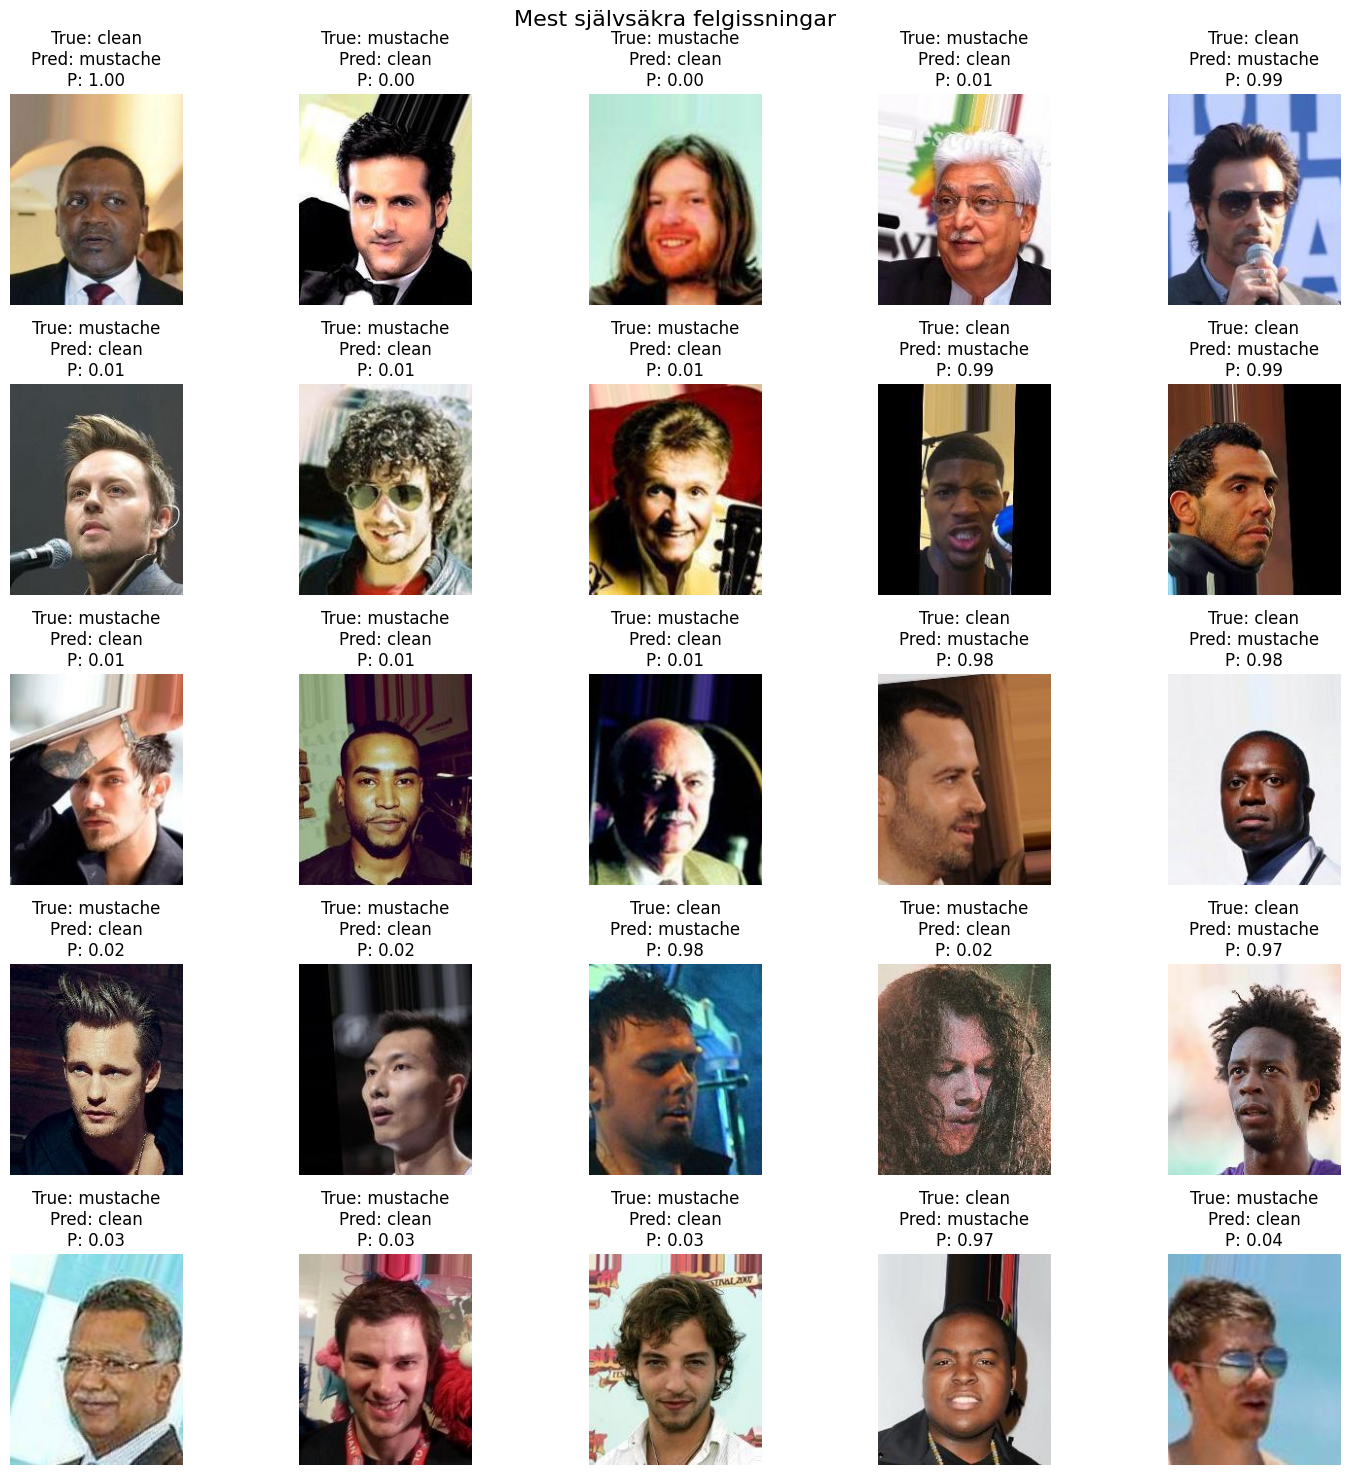

In [47]:
show_images(errors, n=25, title="Mest självsäkra felgissningar")

309


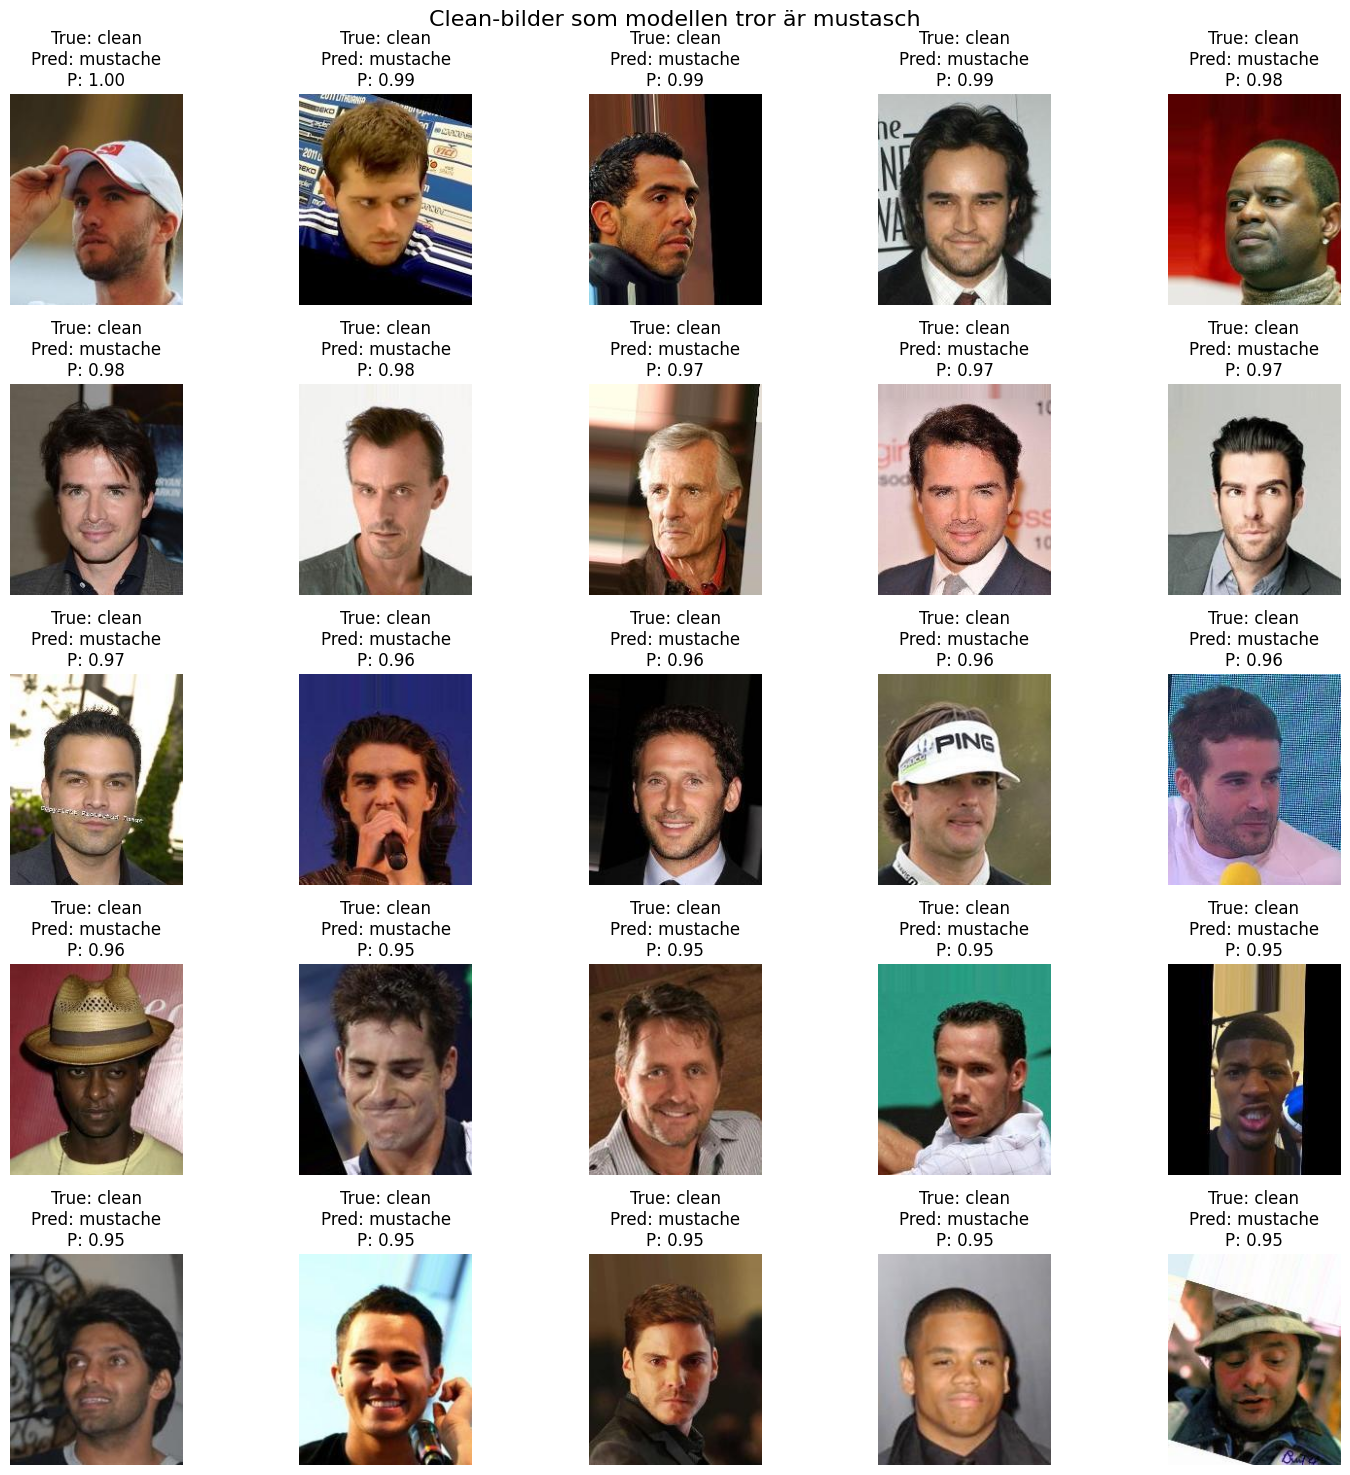

In [55]:
false_mustaches = df[
    (df["true_name"] == "clean") &
    (df["pred_name"] == "mustache")
].copy()

false_mustaches = false_mustaches.sort_values("mustache_prob", ascending=False)

print(len(false_mustaches))
show_images(false_mustaches, n=25, title="Clean-bilder som modellen tror är mustasch")

In [38]:
import os, shutil

REVIEW_DIR = "data/review_candidates"
REVIEW_FALSE_MUSTACHE = os.path.join(REVIEW_DIR, "clean_predicted_mustache")
REVIEW_MISSED_MUSTACHE = os.path.join(REVIEW_DIR, "mustache_predicted_clean")

os.makedirs(REVIEW_FALSE_MUSTACHE, exist_ok=True)
os.makedirs(REVIEW_MISSED_MUSTACHE, exist_ok=True)

In [56]:
import os
import shutil

QUARANTINE_DIR = "data/quarantine/mustache_predicted_clean"
os.makedirs(QUARANTINE_DIR, exist_ok=True)

candidates = df[
    (df["true_name"] == "mustache") &
    (df["pred_name"] == "clean") &
    (df["mustache_prob"] <= 0.05)
]

for _, row in candidates.iterrows():
    src = row["path"]
    dst = os.path.join(QUARANTINE_DIR, row["filename"])

    if os.path.exists(src):
        shutil.move(src, dst)

print(f"Flyttade {len(candidates)} bilder till karantän")

Flyttade 19 bilder till karantän


In [57]:
QUARANTINE_DIR = "data/quarantine/clean_predicted_mustache"
os.makedirs(QUARANTINE_DIR, exist_ok=True)

candidates = df[
    (df["true_name"] == "clean") &
    (df["pred_name"] == "mustache") &
    (df["mustache_prob"] >= 0.50)
]

for _, row in candidates.iterrows():
    src = row["path"]
    dst = os.path.join(QUARANTINE_DIR, row["filename"])

    if os.path.exists(src):
        shutil.move(src, dst)

print(f"Flyttade {len(candidates)} bilder till karantän")

Flyttade 309 bilder till karantän


In [16]:
for t in [0.60, 0.65, 0.70, 0.75, 0.80]:
    n = len(df[
        (df["true_name"] == "clean") &
        (df["pred_name"] == "mustache") &
        (df["mustache_prob"] >= t)
    ])
    print(t, n)

0.6 103
0.65 47
0.7 0
0.75 0
0.8 0


In [18]:
for t in [0.05, 0.10, 0.15, 0.20]:
    n = len(df[
        (df["true_name"] == "mustache") &
        (df["pred_name"] == "clean") &
        (df["mustache_prob"] <= t)
    ])
    print(t, n)

0.05 38
0.1 62
0.15 74
0.2 93
